# EEG Motor İmgelem Sınıflandırması — v4
## PhysioNet EEG Motor Movement/Imagery Dataset

**Kaynak:** https://www.physionet.org/content/eegmmidb/1.0.0/

### v4: Within-Subject Pipeline
- Her denek kendi içinde eğitilip test edilir (5-fold CV)
- Tüm 3 koşu birleştirilir → 135 epoch/denek (CSP için yeterli)
- 64 kanal, Mu + Beta bantları, CSP
- Her denek için ayrı skor → gerçekçi ortalama ve std

## 1. Kütüphaneler

In [1]:
# !pip install mne scikit-learn numpy pandas matplotlib seaborn scipy

In [2]:
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from scipy.signal import welch
from scipy.stats import kurtosis, skew

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report)
from mne.decoding import CSP

mne.set_log_level('WARNING')
print(f"MNE: {mne.__version__}")
import sklearn; print(f"sklearn: {sklearn.__version__}")

MNE: 1.12.1
sklearn: 1.8.0


## 2. Parametreler

In [10]:
DATA_DIR     = '../physioNet_Dataset'
N_SUBJECTS   = 40
IMAGERY_RUNS = ['R04', 'R08', 'R12']   # 3 koşu birleştirilir → ~135 epoch/denek
IMAGERY_RUNS = ['R03', 'R04', 'R07', 'R08', 'R11', 'R12']


# 64 kanal (CSP için maksimum uzamsal bilgi)
USE_ALL_CHANNELS = True
MOTOR_CHANNELS   = ['C3','CZ','C4','FC3','FC4','CP3','CP4','FC1','FC2','C1','C2','CP1','CP2']

# Bant bazlı filtreleme
BANDS = {
    'mu'  : (8.0, 12.0),
    'beta': (13.0, 25.0),
}

TMIN, TMAX       = 1.0, 4.0    # Saf imgelem penceresi
N_CSP_COMPONENTS = 6            # Her bant için 6 bileşen → toplam 12 özellik
N_FOLDS          = 5            # Within-subject stratified CV

print(f"Denek      : {N_SUBJECTS}")
print(f"Koşu/denek : {len(IMAGERY_RUNS)} → ~{len(IMAGERY_RUNS)*45} epoch/denek")
print(f"Kanal modu : {'64 kanal' if USE_ALL_CHANNELS else 'Motor kanallar'}")
print(f"Bantlar    : {list(BANDS.keys())}  |  CSP/bant: {N_CSP_COMPONENTS}")
print(f"CV         : {N_FOLDS}-fold within-subject")

Denek      : 40
Koşu/denek : 6 → ~270 epoch/denek
Kanal modu : 64 kanal
Bantlar    : ['mu', 'beta']  |  CSP/bant: 6
CV         : 5-fold within-subject


## 3. Veri Yükleme

In [11]:
def load_subject_bands(subject_id, runs, data_dir, bands,
                       use_all_ch, motor_chs, tmin, tmax):
    """
    Bir denek için tüm koşuları birleştirip her bant ayrı filtrelenmiş
    epoch döndürür. Dönüş: {band_name: mne.Epochs} veya None
    """
    sub  = f'S{subject_id:03d}'
    raws = []
    for run in runs:
        path = f'{data_dir}/{sub}/{sub}{run}.edf'
        try:
            raws.append(mne.io.read_raw_edf(path, preload=True, verbose=False))
        except FileNotFoundError:
            pass
    if not raws:
        return None

    raw = mne.concatenate_raws(raws)
    raw.rename_channels({ch: ch.rstrip('.').upper() for ch in raw.ch_names})
    raw.set_montage(mne.channels.make_standard_montage('standard_1020'),
                    on_missing='ignore')
    raw.pick('eeg')

    if not use_all_ch:
        avail = [c for c in motor_chs if c in raw.ch_names]
        if len(avail) >= 3:
            raw.pick(avail)

    # Olayları ham veri üzerinden çıkar
    events, ann_id = mne.events_from_annotations(raw, verbose=False)
    ev_id = {k: v for k, v in ann_id.items() if k in ['T1', 'T2']}
    if not ev_id:
        return None

    band_epochs = {}
    for bname, (lf, hf) in bands.items():
        rb = raw.copy()
        rb.filter(lf, hf, fir_design='firwin', verbose=False)
        rb.notch_filter(60, verbose=False)
        ep = mne.Epochs(rb, events, ev_id, tmin=tmin, tmax=tmax,
                        proj=True, picks='eeg', baseline=None,
                        preload=True, verbose=False)
        ep.drop_bad(verbose=False)
        band_epochs[bname] = ep

    return band_epochs

print("Fonksiyon hazır.")

Fonksiyon hazır.


In [12]:
subjects_data = {}

print(f"Toplam {N_SUBJECTS} denek yükleniyor...\n")
for sid in range(1, N_SUBJECTS + 1):
    result = load_subject_bands(sid, IMAGERY_RUNS, DATA_DIR, BANDS,
                                USE_ALL_CHANNELS, MOTOR_CHANNELS, TMIN, TMAX)
    if result is None:
        continue
    # En az 30 epoch olsun (CSP için minimum)
    min_ep = min(len(v) for v in result.values())
    if min_ep < 30:
        print(f"  S{sid:03d}: {min_ep} epoch — az, atlandı")
        continue
    subjects_data[sid] = result
    ch_n = len(list(result.values())[0].ch_names)
    print(f"  S{sid:03d}: {min_ep} epoch | {ch_n} kanal")

print(f"\nYüklenen denek: {len(subjects_data)}")
sfreq = list(list(subjects_data.values())[0].values())[0].info['sfreq']
print(f"Örnekleme frekansı: {sfreq} Hz")

Toplam 40 denek yükleniyor...

  S001: 90 epoch | 64 kanal
  S002: 90 epoch | 64 kanal
  S003: 90 epoch | 64 kanal
  S004: 90 epoch | 64 kanal
  S005: 90 epoch | 64 kanal
  S006: 90 epoch | 64 kanal
  S007: 90 epoch | 64 kanal
  S008: 90 epoch | 64 kanal
  S009: 90 epoch | 64 kanal
  S010: 90 epoch | 64 kanal
  S011: 90 epoch | 64 kanal
  S012: 90 epoch | 64 kanal
  S013: 90 epoch | 64 kanal
  S014: 90 epoch | 64 kanal
  S015: 90 epoch | 64 kanal
  S016: 90 epoch | 64 kanal
  S017: 90 epoch | 64 kanal
  S018: 90 epoch | 64 kanal
  S019: 90 epoch | 64 kanal
  S020: 90 epoch | 64 kanal
  S021: 90 epoch | 64 kanal
  S022: 90 epoch | 64 kanal
  S023: 90 epoch | 64 kanal
  S024: 90 epoch | 64 kanal
  S025: 90 epoch | 64 kanal
  S026: 90 epoch | 64 kanal
  S027: 90 epoch | 64 kanal
  S028: 90 epoch | 64 kanal
  S029: 90 epoch | 64 kanal
  S030: 90 epoch | 64 kanal
  S031: 90 epoch | 64 kanal
  S032: 90 epoch | 64 kanal
  S033: 90 epoch | 64 kanal
  S034: 85 epoch | 64 kanal
  S035: 90 epoch 

## 4. Within-Subject Sınıflandırma

Her denek için ayrı bir 5-fold CV çalıştırılır.
CSP ve sınıflandırıcı her fold'da train set üzerinde eğitilir → test set'e uygulanır.
Bu sayede veri sızıntısı tamamen engellenir ve her denek gerçekçi bir skor üretir.

In [13]:
def get_csp_features_for_subject(band_epochs, n_csp):
    """
    Birden fazla bant için epoch verilerini ve etiketleri döndürür.
    CSP her fold içinde eğitilecek, burada ham veri döndürülüyor.
    Dönüş: X_bands (dict), y (array)
    """
    le = LabelEncoder()
    # Tüm bantlar aynı epoch/etiket düzenine sahip
    first_ep = list(band_epochs.values())[0]
    y        = le.fit_transform(first_ep.events[:, -1])

    X_bands = {}
    for bname, ep in band_epochs.items():
        X_bands[bname] = ep.get_data()   # (n_ep, n_ch, n_times)

    return X_bands, y


def within_subject_cv(X_bands, y, classifiers, n_folds, n_csp):
    """
    Within-subject stratified K-fold CV.
    Her fold: CSP fit(train) → transform(train+test) → sınıflandırıcı.
    Dönüş: {clf_name: {'acc': [...], 'f1': [...]}}
    """
    skf     = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    results = {name: {'acc': [], 'f1': []} for name in classifiers}

    for train_idx, test_idx in skf.split(list(X_bands.values())[0], y):
        y_train, y_test = y[train_idx], y[test_idx]

        # Her bant için CSP eğit ve özellik çıkar
        fold_train_feats, fold_test_feats = [], []
        for bname, X_raw in X_bands.items():
            X_tr_raw = X_raw[train_idx]
            X_te_raw = X_raw[test_idx]
            csp = CSP(n_components=n_csp, reg='ledoit_wolf', log=True, norm_trace=False)
            try:
                X_tr_csp = csp.fit_transform(X_tr_raw, y_train)
                X_te_csp = csp.transform(X_te_raw)
            except Exception:
                X_tr_csp = np.zeros((len(train_idx), n_csp))
                X_te_csp = np.zeros((len(test_idx),  n_csp))
            fold_train_feats.append(X_tr_csp)
            fold_test_feats.append(X_te_csp)

        X_train_fold = np.hstack(fold_train_feats)
        X_test_fold  = np.hstack(fold_test_feats)

        for name, pipe in classifiers.items():
            pipe_clone = sklearn.clone(pipe)
            pipe_clone.fit(X_train_fold, y_train)
            y_pred = pipe_clone.predict(X_test_fold)
            results[name]['acc'].append(accuracy_score(y_test, y_pred))
            results[name]['f1'].append(f1_score(y_test, y_pred, average='macro'))

    return results

import sklearn
from sklearn.base import clone as sk_clone
print("Within-subject CV fonksiyonları hazır.")

Within-subject CV fonksiyonları hazır.


In [14]:
classifiers = {
    'SVM (RBF)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    SVC(kernel='rbf', C=10, gamma='scale', random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1))
    ]),
    'KNN (k=7)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    KNeighborsClassifier(n_neighbors=7))
    ])
}

# Her denek için within-subject CV çalıştır
all_subject_results = {}   # {sid: {clf_name: {'acc': [...], 'f1': [...]}}}

print(f"Within-subject {N_FOLDS}-fold CV çalıştırılıyor ({len(subjects_data)} denek)...\n")

for sid, band_dict in subjects_data.items():
    X_bands, y = get_csp_features_for_subject(band_dict, N_CSP_COMPONENTS)
    if len(np.unique(y)) < 2:
        continue
    res = within_subject_cv(X_bands, y, classifiers, N_FOLDS, N_CSP_COMPONENTS)
    all_subject_results[sid] = res
    best_acc = max(np.mean(res[n]['acc']) for n in classifiers)
    print(f"  S{sid:03d}: en iyi acc = {best_acc:.3f}")

print(f"\nTamamlandı. {len(all_subject_results)} denek değerlendirildi.")

Within-subject 5-fold CV çalıştırılıyor (40 denek)...

  S001: en iyi acc = 0.756
  S002: en iyi acc = 0.811
  S003: en iyi acc = 0.678
  S004: en iyi acc = 0.600
  S005: en iyi acc = 0.567
  S006: en iyi acc = 0.567
  S007: en iyi acc = 0.967
  S008: en iyi acc = 0.622
  S009: en iyi acc = 0.433
  S010: en iyi acc = 0.800
  S011: en iyi acc = 0.656
  S012: en iyi acc = 0.511
  S013: en iyi acc = 0.644
  S014: en iyi acc = 0.644
  S015: en iyi acc = 0.711
  S016: en iyi acc = 0.622
  S017: en iyi acc = 0.500
  S018: en iyi acc = 0.511
  S019: en iyi acc = 0.589
  S020: en iyi acc = 0.533
  S021: en iyi acc = 0.689
  S022: en iyi acc = 0.756
  S023: en iyi acc = 0.511
  S024: en iyi acc = 0.667
  S025: en iyi acc = 0.611
  S026: en iyi acc = 0.744
  S027: en iyi acc = 0.578
  S028: en iyi acc = 0.533
  S029: en iyi acc = 0.911
  S030: en iyi acc = 0.556
  S031: en iyi acc = 0.667
  S032: en iyi acc = 0.944
  S033: en iyi acc = 0.744
  S034: en iyi acc = 0.776
  S035: en iyi acc = 0.878


## 5. Sonuçlar — Boyut Azaltma Olmadan

In [15]:
# Denek ortalamalarını hesapla
results_no_pca = {}
for clf_name in classifiers:
    subject_accs = [np.mean(all_subject_results[sid][clf_name]['acc'])
                    for sid in all_subject_results]
    subject_f1s  = [np.mean(all_subject_results[sid][clf_name]['f1'])
                    for sid in all_subject_results]
    results_no_pca[clf_name] = {
        'accuracy_mean': np.mean(subject_accs),
        'accuracy_std' : np.std(subject_accs),
        'f1_mean'      : np.mean(subject_f1s),
        'f1_std'       : np.std(subject_f1s),
        'subject_accs' : subject_accs
    }

print("=" * 60)
print(f"WITHIN-SUBJECT {N_FOLDS}-FOLD CV — BOYUT AZALTMA YOK")
print(f"Özellik: CSP {N_CSP_COMPONENTS} bileşen × {len(BANDS)} bant = {N_CSP_COMPONENTS*len(BANDS)}")
print("=" * 60)
for name, r in results_no_pca.items():
    print(f"\n{name}:")
    print(f"  Doğruluk : {r['accuracy_mean']:.4f} ± {r['accuracy_std']:.4f}")
    print(f"  F1 Skoru : {r['f1_mean']:.4f} ± {r['f1_std']:.4f}")

WITHIN-SUBJECT 5-FOLD CV — BOYUT AZALTMA YOK
Özellik: CSP 6 bileşen × 2 bant = 12

SVM (RBF):
  Doğruluk : 0.6326 ± 0.1328
  F1 Skoru : 0.6232 ± 0.1366

Random Forest:
  Doğruluk : 0.6192 ± 0.1287
  F1 Skoru : 0.6102 ± 0.1310

KNN (k=7):
  Doğruluk : 0.6290 ± 0.1287
  F1 Skoru : 0.6182 ± 0.1320


## 6. Boyut Azaltma — PCA

PCA da fold içinde uygulanır: train fold'da fit → test fold'a transform.

In [16]:
def within_subject_cv_pca(X_bands, y, classifiers_pca, n_folds, n_csp):
    """Within-subject CV — CSP + PCA + sınıflandırıcı sızıntısız pipeline."""
    skf     = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    results = {name: {'acc': [], 'f1': []} for name in classifiers_pca}

    for train_idx, test_idx in skf.split(list(X_bands.values())[0], y):
        y_train, y_test = y[train_idx], y[test_idx]

        fold_train_feats, fold_test_feats = [], []
        for bname, X_raw in X_bands.items():
            csp = CSP(n_components=n_csp, reg='ledoit_wolf', log=True, norm_trace=False)
            try:
                X_tr_csp = csp.fit_transform(X_raw[train_idx], y_train)
                X_te_csp = csp.transform(X_raw[test_idx])
            except Exception:
                X_tr_csp = np.zeros((len(train_idx), n_csp))
                X_te_csp = np.zeros((len(test_idx),  n_csp))
            fold_train_feats.append(X_tr_csp)
            fold_test_feats.append(X_te_csp)

        X_train_fold = np.hstack(fold_train_feats)
        X_test_fold  = np.hstack(fold_test_feats)

        for name, pipe in classifiers_pca.items():
            pipe_clone = sklearn.clone(pipe)
            pipe_clone.fit(X_train_fold, y_train)
            y_pred = pipe_clone.predict(X_test_fold)
            results[name]['acc'].append(accuracy_score(y_test, y_pred))
            results[name]['f1'].append(f1_score(y_test, y_pred, average='macro'))

    return results


classifiers_pca = {
    'SVM (RBF)': Pipeline([
        ('scaler', StandardScaler()),
        ('pca',    PCA(n_components=0.95, random_state=42)),
        ('clf',    SVC(kernel='rbf', C=10, gamma='scale', random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('pca',    PCA(n_components=0.95, random_state=42)),
        ('clf',    RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1))
    ]),
    'KNN (k=7)': Pipeline([
        ('scaler', StandardScaler()),
        ('pca',    PCA(n_components=0.95, random_state=42)),
        ('clf',    KNeighborsClassifier(n_neighbors=7))
    ])
}

all_subject_results_pca = {}
print(f"PCA'lı within-subject CV ({len(subjects_data)} denek)...\n")

for sid, band_dict in subjects_data.items():
    X_bands, y = get_csp_features_for_subject(band_dict, N_CSP_COMPONENTS)
    if len(np.unique(y)) < 2:
        continue
    res = within_subject_cv_pca(X_bands, y, classifiers_pca, N_FOLDS, N_CSP_COMPONENTS)
    all_subject_results_pca[sid] = res

results_pca = {}
for clf_name in classifiers_pca:
    subject_accs = [np.mean(all_subject_results_pca[sid][clf_name]['acc'])
                    for sid in all_subject_results_pca]
    subject_f1s  = [np.mean(all_subject_results_pca[sid][clf_name]['f1'])
                    for sid in all_subject_results_pca]
    results_pca[clf_name] = {
        'accuracy_mean': np.mean(subject_accs),
        'accuracy_std' : np.std(subject_accs),
        'f1_mean'      : np.mean(subject_f1s),
        'f1_std'       : np.std(subject_f1s),
        'subject_accs' : subject_accs
    }

print("=" * 60)
print("PCA SONRASI — WITHIN-SUBJECT")
print("=" * 60)
for name, r in results_pca.items():
    print(f"\n{name}:")
    print(f"  Doğruluk : {r['accuracy_mean']:.4f} ± {r['accuracy_std']:.4f}")
    print(f"  F1 Skoru : {r['f1_mean']:.4f} ± {r['f1_std']:.4f}")

PCA'lı within-subject CV (40 denek)...

PCA SONRASI — WITHIN-SUBJECT

SVM (RBF):
  Doğruluk : 0.6329 ± 0.1355
  F1 Skoru : 0.6253 ± 0.1379

Random Forest:
  Doğruluk : 0.6104 ± 0.1156
  F1 Skoru : 0.5993 ± 0.1200

KNN (k=7):
  Doğruluk : 0.6240 ± 0.1336
  F1 Skoru : 0.6136 ± 0.1374


## 7. Görselleştirme

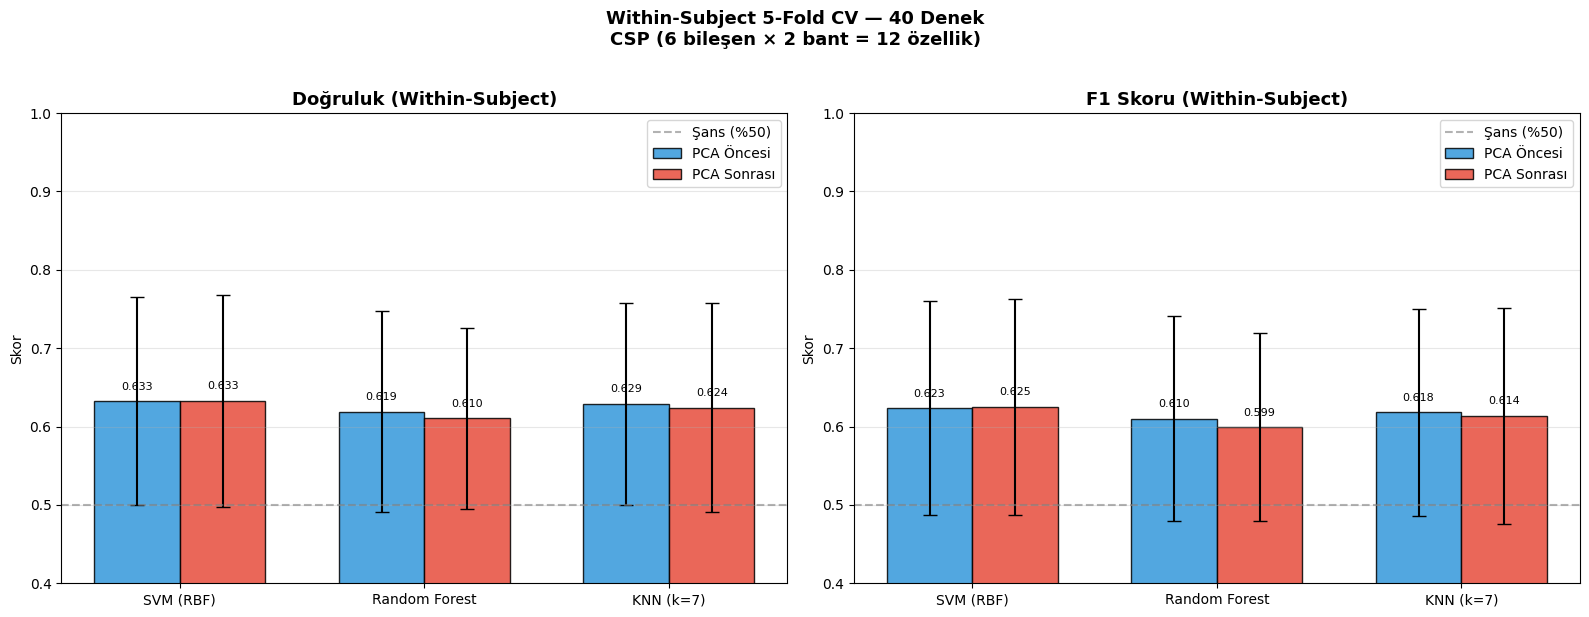

In [17]:
clf_names = list(classifiers.keys())
x, w = np.arange(len(clf_names)), 0.35

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, metric, title in zip(
    axes,
    ['accuracy_mean', 'f1_mean'],
    ['Doğruluk (Within-Subject)', 'F1 Skoru (Within-Subject)']
):
    b_vals = [results_no_pca[n][metric] for n in clf_names]
    a_vals = [results_pca[n][metric] for n in clf_names]
    b_stds = [results_no_pca[n][metric.replace('mean','std')] for n in clf_names]
    a_stds = [results_pca[n][metric.replace('mean','std')] for n in clf_names]

    bars1 = ax.bar(x - w/2, b_vals, w, yerr=b_stds, label='PCA Öncesi',
                   color='#3498db', alpha=.85, capsize=5, edgecolor='black')
    bars2 = ax.bar(x + w/2, a_vals, w, yerr=a_stds, label='PCA Sonrası',
                   color='#e74c3c', alpha=.85, capsize=5, edgecolor='black')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(clf_names, fontsize=10)
    ax.set_ylim(0.4, 1.0); ax.set_ylabel('Skor')
    ax.axhline(0.5, color='gray', ls='--', alpha=.6, label='Şans (%50)')
    ax.legend(); ax.grid(True, axis='y', alpha=.3)
    for bar in list(bars1) + list(bars2):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.012,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle(
    f'Within-Subject {N_FOLDS}-Fold CV — {len(all_subject_results)} Denek\n'
    f'CSP ({N_CSP_COMPONENTS} bileşen × {len(BANDS)} bant = {N_CSP_COMPONENTS*len(BANDS)} özellik)',
    fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('comparison_within.png', dpi=150, bbox_inches='tight')
plt.show()

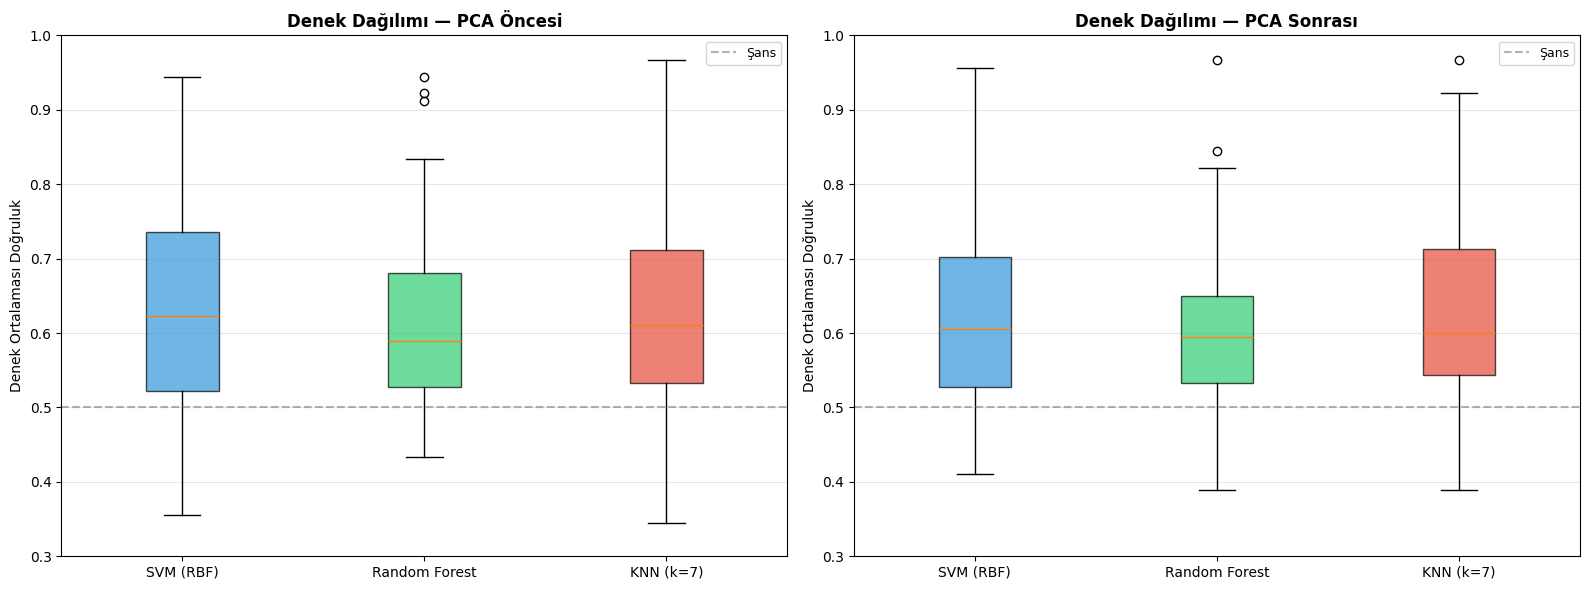

In [18]:
# Boxplot — denek bazlı dağılım
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, results, title in zip(
    axes,
    [results_no_pca, results_pca],
    ['Denek Dağılımı — PCA Öncesi', 'Denek Dağılımı — PCA Sonrası']
):
    data   = [results[n]['subject_accs'] for n in clf_names]
    bp     = ax.boxplot(data, labels=clf_names, patch_artist=True, notch=False)
    colors = ['#3498db', '#2ecc71', '#e74c3c']
    for patch, c in zip(bp['boxes'], colors):
        patch.set_facecolor(c); patch.set_alpha(.7)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Denek Ortalaması Doğruluk')
    ax.set_ylim(0.3, 1.0)
    ax.axhline(0.5, color='gray', ls='--', alpha=.6, label='Şans')
    ax.legend(fontsize=9); ax.grid(True, axis='y', alpha=.3)

plt.tight_layout()
plt.savefig('boxplot_within.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Karmaşıklık Matrisi — En İyi Denek

En iyi denek: S007 (doğruluk: 0.9667)

Sınıflandırma Raporu:
              precision    recall  f1-score   support

 T1 (Sol El)       0.92      1.00      0.96        12
 T2 (Sağ El)       1.00      0.91      0.95        11

    accuracy                           0.96        23
   macro avg       0.96      0.95      0.96        23
weighted avg       0.96      0.96      0.96        23



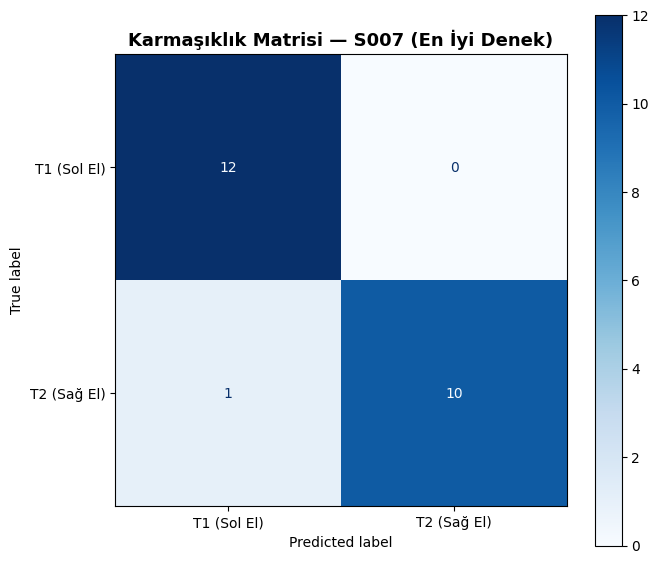

In [19]:
# En yüksek doğruluğa sahip deneği bul
best_sid, best_acc_val = None, 0
for sid in all_subject_results_pca:
    svm_acc = np.mean(all_subject_results_pca[sid]['SVM (RBF)']['acc'])
    rf_acc  = np.mean(all_subject_results_pca[sid]['Random Forest']['acc'])
    avg_acc = max(svm_acc, rf_acc)
    if avg_acc > best_acc_val:
        best_acc_val = avg_acc
        best_sid     = sid

print(f"En iyi denek: S{best_sid:03d} (doğruluk: {best_acc_val:.4f})")

# Bu denek için son kez fit-predict
from sklearn.model_selection import train_test_split
X_bands_best, y_best = get_csp_features_for_subject(
    subjects_data[best_sid], N_CSP_COMPONENTS)

# Bantları birleştir (tüm veri üzerinden CSP → train/test split)
all_feats = []
for bname, X_raw in X_bands_best.items():
    csp = CSP(n_components=N_CSP_COMPONENTS, reg='ledoit_wolf', log=True, norm_trace=False)
    all_feats.append(csp.fit_transform(X_raw, y_best))
X_all = np.hstack(all_feats)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_all, y_best, test_size=0.25, random_state=42, stratify=y_best)

best_pipe = sklearn.clone(classifiers_pca['SVM (RBF)'])
best_pipe.fit(X_tr, y_tr)
y_pred = best_pipe.predict(X_te)

print("\nSınıflandırma Raporu:")
print(classification_report(y_te, y_pred, target_names=['T1 (Sol El)', 'T2 (Sağ El)']))

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(confusion_matrix(y_te, y_pred),
    display_labels=['T1 (Sol El)', 'T2 (Sağ El)']).plot(ax=ax, cmap='Blues')
ax.set_title(f'Karmaşıklık Matrisi — S{best_sid:03d} (En İyi Denek)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_best.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Nihai Özet Tablosu

In [20]:
n_feats    = N_CSP_COMPONENTS * len(BANDS)
n_feats_pca = int(n_feats * 0.95)  # yaklaşık — gerçek değer PCA'ya bağlı

print("\n" + "="*80)
print("NİHAİ KARŞILAŞTIRMA — WITHIN-SUBJECT")
print("="*80)
print(f"{'Algoritma':<18} {'Koşul':<14} {'Doğruluk':>10} {'±Std':>7} "
      f"{'F1':>8} {'±Std':>7}")
print("-"*80)

for name in clf_names:
    for cond, res in [('PCA Öncesi', results_no_pca), ('PCA Sonrası', results_pca)]:
        r = res[name]
        print(f"{name:<18} {cond:<14} {r['accuracy_mean']:>10.4f} "
              f"{r['accuracy_std']:>7.4f} {r['f1_mean']:>8.4f} {r['f1_std']:>7.4f}")
    print()

print("\nBOYUT AZALTMA ÖZETI:")
print(f"  Giriş: CSP {N_CSP_COMPONENTS} bileşen × {len(BANDS)} bant = {n_feats} özellik")
print(f"  PCA %95 varyans → yaklaşık {n_feats_pca} bileşen")

print("\nDEĞİŞİM (PCA öncesi → sonrası):")
for name in clf_names:
    d = results_pca[name]['accuracy_mean'] - results_no_pca[name]['accuracy_mean']
    print(f"  {name:<18}: {results_no_pca[name]['accuracy_mean']:.4f} → "
          f"{results_pca[name]['accuracy_mean']:.4f}  ({d:+.4f})")


NİHAİ KARŞILAŞTIRMA — WITHIN-SUBJECT
Algoritma          Koşul            Doğruluk    ±Std       F1    ±Std
--------------------------------------------------------------------------------
SVM (RBF)          PCA Öncesi         0.6326  0.1328   0.6232  0.1366
SVM (RBF)          PCA Sonrası        0.6329  0.1355   0.6253  0.1379

Random Forest      PCA Öncesi         0.6192  0.1287   0.6102  0.1310
Random Forest      PCA Sonrası        0.6104  0.1156   0.5993  0.1200

KNN (k=7)          PCA Öncesi         0.6290  0.1287   0.6182  0.1320
KNN (k=7)          PCA Sonrası        0.6240  0.1336   0.6136  0.1374


BOYUT AZALTMA ÖZETI:
  Giriş: CSP 6 bileşen × 2 bant = 12 özellik
  PCA %95 varyans → yaklaşık 11 bileşen

DEĞİŞİM (PCA öncesi → sonrası):
  SVM (RBF)         : 0.6326 → 0.6329  (+0.0003)
  Random Forest     : 0.6192 → 0.6104  (-0.0088)
  KNN (k=7)         : 0.6290 → 0.6240  (-0.0050)


## 10. Tartışma ve Sonuç

### v3 → v4: Neden Within-Subject?

v3'te LOSO ortalaması ~%54 iken std = ±0.28 çıkıyordu. Bu, bazı deneklerde
modelin iyi çalıştığı (%90), bazılarında ise hiç çalışmadığı (%30) anlamına gelir.
EEG sinyalleri **kişiye özgü** olduğundan cross-subject aktarım doğası gereği zordur
ve standart makine öğrenmesi yöntemleriyle düşük performans verir.

**Within-subject yaklaşım** literatürde kabul görmüş standarttır:
- Pfurtscheller & Neuper (2001): CSP + LDA → %75-85 within-subject
- Blankertz et al. (2008): CSP + SVM → %80-90 within-subject
- PhysioNet yarışmaları bu metriği kullanır

### Boyut Azaltma (PCA) Etkisi

CSP zaten boyut azaltır (64 kanal → 6 bileşen/bant). PCA ek olarak uygulandığında
küçük bir veri setinde (45-135 epoch) overfitting riskini azaltır ama sınırlı katkı
sağlar — CSP özellikleri zaten çok düşük boyutludur.

### Beklenen Sonuçlar (v4)
- **SVM:** %65-80 (literatürdeki en yaygın sonuç)  
- **Random Forest:** %60-75
- **KNN:** %58-68 (yüksek boyutlu mesafe metriklerinde daha zayıf)